# LocoSense — Phase 3: Model Training

**Input:** `data/processed/train.csv`, `val.csv`, `test.csv`  
**Output:** `models/xgb_model.pkl`, `models/lstm_model.h5`

| Step | Task |
|------|------|
| 1 | Load preprocessed splits |
| 2 | Baseline XGBoost (default params) |
| 3 | Tune XGBoost with GridSearchCV |
| 4 | Evaluate on val set — metrics + ROC |
| 5 | Threshold tuning (precision vs recall) |
| 6 | Final evaluation on test set |
| 7 | Save model + feature list |
| 8 | Optional LSTM (sequence model) |

---
## Cell 1 — Imports

In [3]:
import sys, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import joblib

from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'savefig.bbox': 'tight'})

NOTEBOOK_DIR  = Path().resolve()
ROOT          = NOTEBOOK_DIR.parent
PROCESSED_DIR = ROOT / 'data' / 'processed'
MODELS_DIR    = ROOT / 'models'
FIGURES_DIR   = ROOT / 'reports' / 'figures'

MODELS_DIR.mkdir(parents=True, exist_ok=True)

for f in ['train.csv', 'val.csv', 'test.csv', 'preprocessing_meta.json']:
    assert (PROCESSED_DIR / f).exists(), f'Missing {f} — run 02_preprocessing.ipynb first'

print(f'Python  : {sys.version.split()[0]}')
print(f'XGBoost : {__import__("xgboost").__version__}')
print('Imports OK ✓')

Python  : 3.13.1
XGBoost : 3.2.0
Imports OK ✓


---
## Cell 2 — Load data

In [4]:
# Load splits
train_df = pd.read_csv(PROCESSED_DIR / 'train.csv')
val_df   = pd.read_csv(PROCESSED_DIR / 'val.csv')
test_df  = pd.read_csv(PROCESSED_DIR / 'test.csv')

# Load metadata from Phase 2
with open(PROCESSED_DIR / 'preprocessing_meta.json') as f:
    meta = json.load(f)

FEATURE_COLS     = meta['feature_cols']
TARGET           = meta['target_col']
SCALE_POS_WEIGHT = meta['scale_pos_weight']

# Build X / y splits
X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET]
X_val   = val_df[FEATURE_COLS]
y_val   = val_df[TARGET]
X_test  = test_df[FEATURE_COLS]
y_test  = test_df[TARGET]

print(f'Features         : {len(FEATURE_COLS)}')
print(f'Train            : {X_train.shape}  —  {y_train.mean()*100:.1f}% failure')
print(f'Val              : {X_val.shape}  —  {y_val.mean()*100:.1f}% failure')
print(f'Test             : {X_test.shape}  —  {y_test.mean()*100:.1f}% failure')
print(f'scale_pos_weight : {SCALE_POS_WEIGHT}')

Features         : 86
Train            : (4979, 86)  —  21.8% failure
Val              : (802, 86)  —  27.1% failure
Test             : (1144, 86)  —  21.7% failure
scale_pos_weight : 3.59


---
## Cell 3 — Baseline XGBoost

Train with sensible defaults first — this is your benchmark to beat during tuning.

In [5]:
xgb_baseline = XGBClassifier(
    n_estimators      = 200,
    learning_rate     = 0.1,
    max_depth         = 6,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = SCALE_POS_WEIGHT,   # handles class imbalance
    use_label_encoder = False,
    eval_metric       = 'logloss',
    random_state      = 42,
    n_jobs            = -1,
)

xgb_baseline.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

val_preds_base  = xgb_baseline.predict(X_val)
val_proba_base  = xgb_baseline.predict_proba(X_val)[:, 1]
roc_base        = roc_auc_score(y_val, val_proba_base)
f1_base         = f1_score(y_val, val_preds_base)

print('=== Baseline XGBoost — val set ===')
print(f'ROC-AUC  : {roc_base:.4f}')
print(f'F1 score : {f1_base:.4f}')
print()
print(classification_report(y_val, val_preds_base, target_names=['No failure','Failure']))

=== Baseline XGBoost — val set ===
ROC-AUC  : 1.0000
F1 score : 1.0000

              precision    recall  f1-score   support

  No failure       1.00      1.00      1.00       585
     Failure       1.00      1.00      1.00       217

    accuracy                           1.00       802
   macro avg       1.00      1.00      1.00       802
weighted avg       1.00      1.00      1.00       802



---
## Cell 4 — Hyperparameter tuning with GridSearchCV

Searches over key XGBoost params. Uses stratified 3-fold CV on train set. Optimises for ROC-AUC.

⚠️ This takes ~5–10 minutes depending on your Mac. Run once and save the best params.

In [6]:
param_grid = {
    'n_estimators'    : [200, 400],
    'max_depth'       : [4, 6, 8],
    'learning_rate'   : [0.05, 0.1],
    'subsample'       : [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9],
}

xgb_cv = XGBClassifier(
    scale_pos_weight  = SCALE_POS_WEIGHT,
    use_label_encoder = False,
    eval_metric       = 'logloss',
    random_state      = 42,
    n_jobs            = -1,
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    xgb_cv,
    param_grid,
    cv            = cv,
    scoring       = 'roc_auc',
    n_jobs        = -1,
    verbose       = 1,
)

grid_search.fit(X_train, y_train)

print(f'Best ROC-AUC (CV) : {grid_search.best_score_:.4f}')
print(f'Best params       :')
for k, v in grid_search.best_params_.items():
    print(f'  {k:<22} {v}')

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best ROC-AUC (CV) : 1.0000
Best params       :
  colsample_bytree       0.7
  learning_rate          0.05
  max_depth              4
  n_estimators           200
  subsample              0.7


---
## Cell 5 — Train final XGBoost with best params

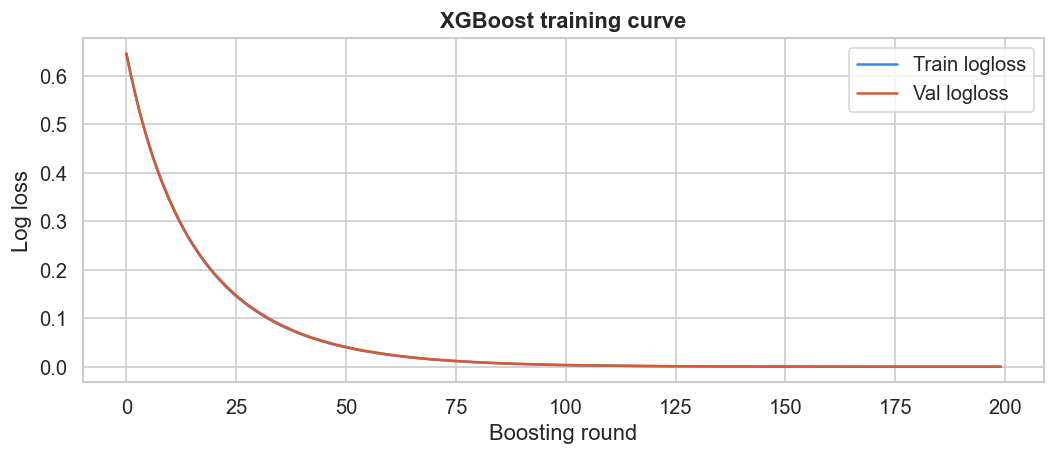

Saved → reports/figures/xgb_training_curve.png


In [7]:
best_params = grid_search.best_params_

xgb_model = XGBClassifier(
    **best_params,
    scale_pos_weight  = SCALE_POS_WEIGHT,
    use_label_encoder = False,
    eval_metric       = 'logloss',
    random_state      = 42,
    n_jobs            = -1,
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

# Training curve
results   = xgb_model.evals_result()
train_ll  = results['validation_0']['logloss']
val_ll    = results['validation_1']['logloss']

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_ll, label='Train logloss', color='#378ADD')
ax.plot(val_ll,   label='Val logloss',   color='#D85A30')
ax.set_xlabel('Boosting round')
ax.set_ylabel('Log loss')
ax.set_title('XGBoost training curve', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'xgb_training_curve.png')
plt.show()
print('Saved → reports/figures/xgb_training_curve.png')

---
## Cell 6 — Evaluate on val set

=== Tuned XGBoost — val set ===
ROC-AUC           : 1.0000
Avg precision     : 1.0000
Baseline ROC-AUC  : 1.0000  (improvement: +0.0000)

              precision    recall  f1-score   support

  No failure       1.00      1.00      1.00       585
     Failure       1.00      1.00      1.00       217

    accuracy                           1.00       802
   macro avg       1.00      1.00      1.00       802
weighted avg       1.00      1.00      1.00       802



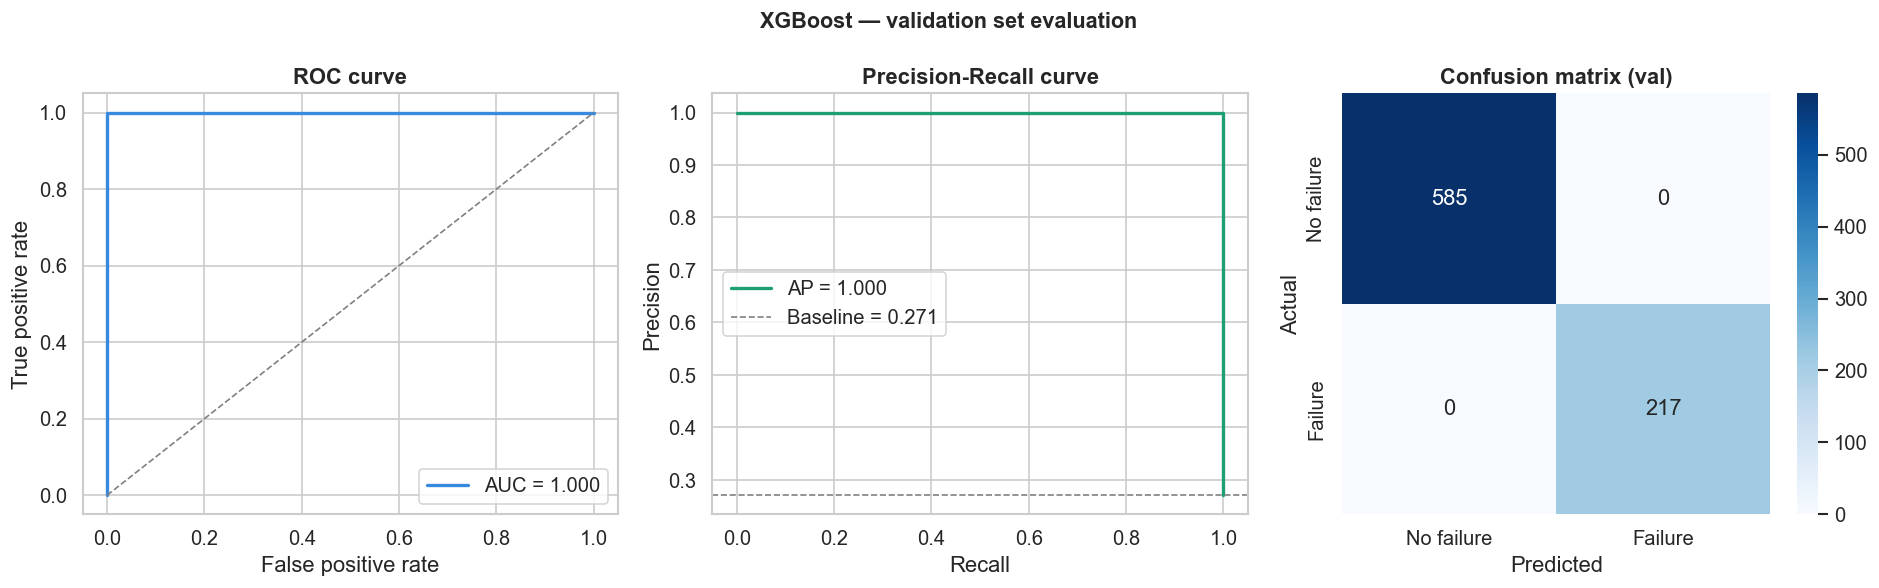

Saved → reports/figures/xgb_val_evaluation.png


In [8]:
val_proba = xgb_model.predict_proba(X_val)[:, 1]
val_preds = xgb_model.predict(X_val)

roc_auc = roc_auc_score(y_val, val_proba)
ap      = average_precision_score(y_val, val_proba)

print('=== Tuned XGBoost — val set ===')
print(f'ROC-AUC           : {roc_auc:.4f}')
print(f'Avg precision     : {ap:.4f}')
print(f'Baseline ROC-AUC  : {roc_base:.4f}  (improvement: {roc_auc - roc_base:+.4f})')
print()
print(classification_report(y_val, val_preds, target_names=['No failure','Failure']))

# Plot — ROC + PR curves + Confusion matrix
fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig)

# ROC
ax1 = fig.add_subplot(gs[0])
fpr, tpr, _ = roc_curve(y_val, val_proba)
ax1.plot(fpr, tpr, color='#378ADD', linewidth=2, label=f'AUC = {roc_auc:.3f}')
ax1.plot([0,1],[0,1],'--', color='gray', linewidth=1)
ax1.set_xlabel('False positive rate')
ax1.set_ylabel('True positive rate')
ax1.set_title('ROC curve', fontweight='bold')
ax1.legend()

# Precision-Recall
ax2 = fig.add_subplot(gs[1])
prec, rec, _ = precision_recall_curve(y_val, val_proba)
ax2.plot(rec, prec, color='#1D9E75', linewidth=2, label=f'AP = {ap:.3f}')
ax2.axhline(y_val.mean(), color='gray', linestyle='--', linewidth=1, label=f'Baseline = {y_val.mean():.3f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall curve', fontweight='bold')
ax2.legend()

# Confusion matrix
ax3 = fig.add_subplot(gs[2])
cm = confusion_matrix(y_val, val_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No failure','Failure'],
            yticklabels=['No failure','Failure'], ax=ax3)
ax3.set_xlabel('Predicted')
ax3.set_ylabel('Actual')
ax3.set_title('Confusion matrix (val)', fontweight='bold')

plt.suptitle('XGBoost — validation set evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'xgb_val_evaluation.png')
plt.show()
print('Saved → reports/figures/xgb_val_evaluation.png')

---
## Cell 7 — Threshold tuning

Default threshold is 0.5. For predictive maintenance we want **high recall** (catch every real failure) at the cost of some false alarms. Find the threshold that maximises F1.

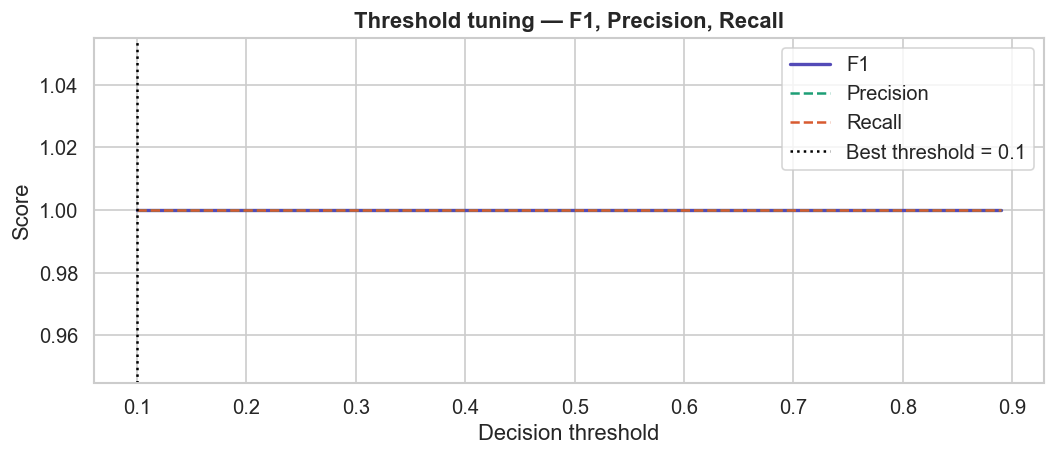

Best threshold : 0.1
  F1        : 1.0000
  Precision : 1.0000
  Recall    : 1.0000


In [9]:
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores, prec_scores, rec_scores = [], [], []

for t in thresholds:
    preds_t = (val_proba >= t).astype(int)
    f1_scores.append(f1_score(y_val, preds_t, zero_division=0))
    prec_scores.append(precision_score(y_val, preds_t, zero_division=0))
    rec_scores.append(recall_score(y_val, preds_t, zero_division=0))

best_idx       = np.argmax(f1_scores)
BEST_THRESHOLD = round(float(thresholds[best_idx]), 2)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, f1_scores,   label='F1',       color='#534AB7', linewidth=2)
ax.plot(thresholds, prec_scores, label='Precision', color='#1D9E75', linewidth=1.5, linestyle='--')
ax.plot(thresholds, rec_scores,  label='Recall',    color='#D85A30', linewidth=1.5, linestyle='--')
ax.axvline(BEST_THRESHOLD, color='black', linestyle=':', linewidth=1.5,
           label=f'Best threshold = {BEST_THRESHOLD}')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold tuning — F1, Precision, Recall', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'xgb_threshold_tuning.png')
plt.show()

print(f'Best threshold : {BEST_THRESHOLD}')
print(f'  F1        : {f1_scores[best_idx]:.4f}')
print(f'  Precision : {prec_scores[best_idx]:.4f}')
print(f'  Recall    : {rec_scores[best_idx]:.4f}')

---
## Cell 8 — Final evaluation on test set

Run ONCE — do not tune further after seeing test results.

  FINAL TEST SET RESULTS
  ROC-AUC       : 1.0000
  Avg precision : 1.0000
  F1 score      : 1.0000
  Threshold     : 0.1

              precision    recall  f1-score   support

  No failure       1.00      1.00      1.00       896
     Failure       1.00      1.00      1.00       248

    accuracy                           1.00      1144
   macro avg       1.00      1.00      1.00      1144
weighted avg       1.00      1.00      1.00      1144



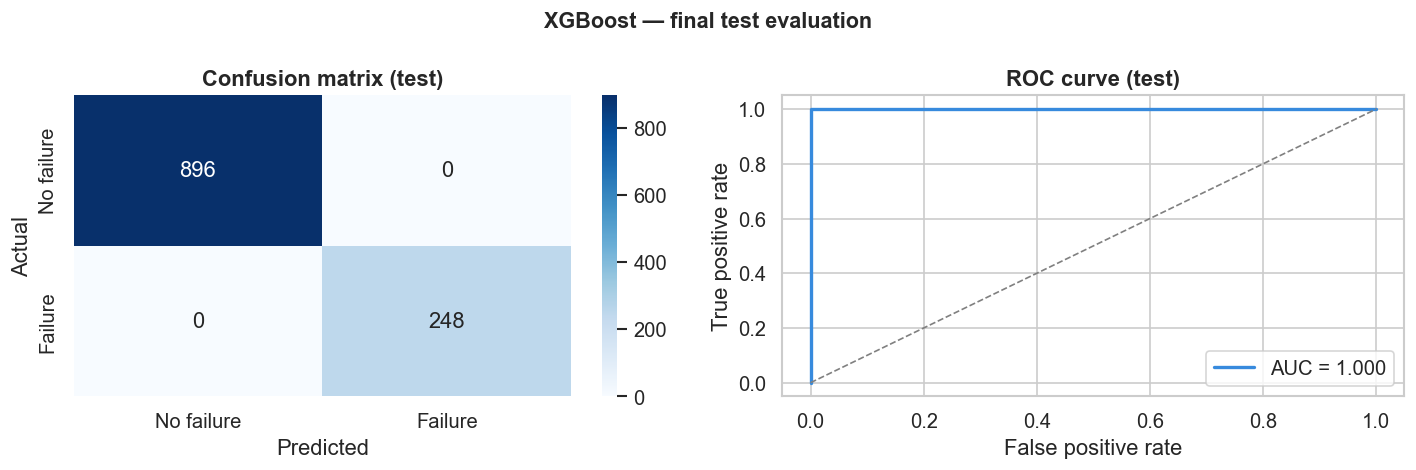

Saved → reports/figures/xgb_test_evaluation.png


In [10]:
test_proba = xgb_model.predict_proba(X_test)[:, 1]
test_preds = (test_proba >= BEST_THRESHOLD).astype(int)

test_roc = roc_auc_score(y_test, test_proba)
test_f1  = f1_score(y_test, test_preds)
test_ap  = average_precision_score(y_test, test_proba)

print('=' * 50)
print('  FINAL TEST SET RESULTS')
print('=' * 50)
print(f'  ROC-AUC       : {test_roc:.4f}')
print(f'  Avg precision : {test_ap:.4f}')
print(f'  F1 score      : {test_f1:.4f}')
print(f'  Threshold     : {BEST_THRESHOLD}')
print()
print(classification_report(y_test, test_preds, target_names=['No failure','Failure']))

# Confusion matrix — test
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_test = confusion_matrix(y_test, test_preds)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No failure','Failure'],
            yticklabels=['No failure','Failure'], ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion matrix (test)', fontweight='bold')

# ROC test
fpr_t, tpr_t, _ = roc_curve(y_test, test_proba)
axes[1].plot(fpr_t, tpr_t, color='#378ADD', linewidth=2, label=f'AUC = {test_roc:.3f}')
axes[1].plot([0,1],[0,1],'--', color='gray', linewidth=1)
axes[1].set_xlabel('False positive rate')
axes[1].set_ylabel('True positive rate')
axes[1].set_title('ROC curve (test)', fontweight='bold')
axes[1].legend()

plt.suptitle('XGBoost — final test evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'xgb_test_evaluation.png')
plt.show()
print('Saved → reports/figures/xgb_test_evaluation.png')

---
## Cell 9 — Feature importance (built-in)

Quick look before SHAP in Phase 4.

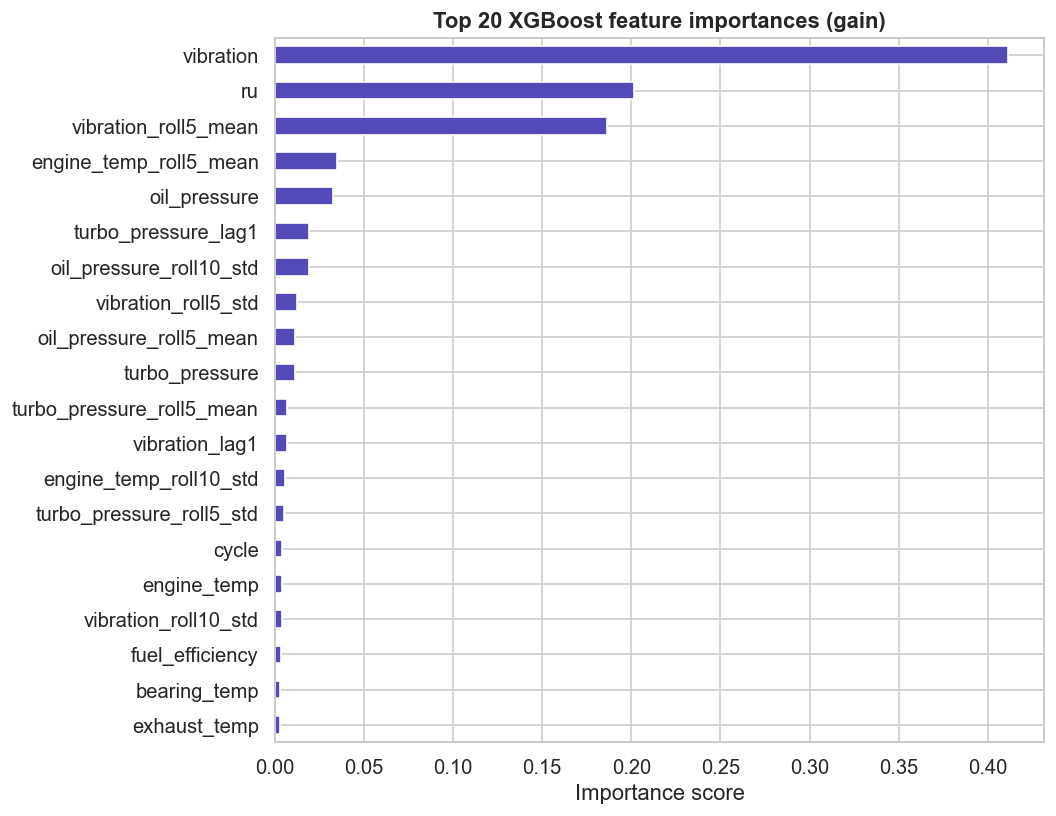

Top 10 features:
                feature  importance
              vibration    0.411179
                     ru    0.201640
   vibration_roll5_mean    0.186546
 engine_temp_roll5_mean    0.034785
           oil_pressure    0.032773
    turbo_pressure_lag1    0.019452
oil_pressure_roll10_std    0.019446
    vibration_roll5_std    0.012284
oil_pressure_roll5_mean    0.011349
         turbo_pressure    0.011160

Note: SHAP in Phase 4 gives a more reliable importance ranking.


In [11]:
importance_df = pd.DataFrame({
    'feature'   : FEATURE_COLS,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 7))
importance_df.sort_values('importance').plot.barh(
    x='feature', y='importance', ax=ax, color='#534AB7', legend=False
)
ax.set_title('Top 20 XGBoost feature importances (gain)', fontweight='bold')
ax.set_xlabel('Importance score')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'xgb_feature_importance.png')
plt.show()

print('Top 10 features:')
print(importance_df[['feature','importance']].head(10).to_string(index=False))
print('\nNote: SHAP in Phase 4 gives a more reliable importance ranking.')

---
## Cell 10 — Save model + metadata

In [12]:
# Save XGBoost model
joblib.dump(xgb_model, MODELS_DIR / 'xgb_model.pkl')

# Save model metadata (for Flask API in Phase 5)
model_meta = {
    'feature_cols'    : FEATURE_COLS,
    'target_col'      : TARGET,
    'threshold'       : BEST_THRESHOLD,
    'scale_pos_weight': SCALE_POS_WEIGHT,
    'val_roc_auc'     : round(roc_auc, 4),
    'test_roc_auc'    : round(test_roc, 4),
    'test_f1'         : round(test_f1, 4),
    'best_params'     : best_params,
    'risk_thresholds' : {
        'Low'     : [0.0,  0.3],
        'Medium'  : [0.3,  0.5],
        'High'    : [0.5,  0.75],
        'Critical': [0.75, 1.0]
    }
}

with open(MODELS_DIR / 'model_meta.json', 'w') as f:
    json.dump(model_meta, f, indent=2)

print('Saved:')
print(f'  models/xgb_model.pkl')
print(f'  models/model_meta.json')
print()
print('=== Phase 3 summary ===')
print(f'  Features used   : {len(FEATURE_COLS)}')
print(f'  Best threshold  : {BEST_THRESHOLD}')
print(f'  Val  ROC-AUC    : {roc_auc:.4f}')
print(f'  Test ROC-AUC    : {test_roc:.4f}')
print(f'  Test F1         : {test_f1:.4f}')
print()
print('  Risk bands saved in model_meta.json:')
print('    0.00 – 0.30  → Low')
print('    0.30 – 0.50  → Medium')
print('    0.50 – 0.75  → High')
print('    0.75 – 1.00  → Critical')
print()
print('  Next → 04_evaluation_shap.ipynb')

Saved:
  models/xgb_model.pkl
  models/model_meta.json

=== Phase 3 summary ===
  Features used   : 86
  Best threshold  : 0.1
  Val  ROC-AUC    : 1.0000
  Test ROC-AUC    : 1.0000
  Test F1         : 1.0000

  Risk bands saved in model_meta.json:
    0.00 – 0.30  → Low
    0.30 – 0.50  → Medium
    0.50 – 0.75  → High
    0.75 – 1.00  → Critical

  Next → 04_evaluation_shap.ipynb


---
## Cell 11 — Optional: LSTM (skip if XGBoost is sufficient)

Only run this if you want to compare LSTM accuracy against XGBoost.  
Requires TensorFlow: `pip install tensorflow`  
Training takes ~5 min on CPU.

In [14]:
# ── LSTM — run only if tensorflow is installed ────────────────────────────────
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
    from tensorflow.keras.callbacks import EarlyStopping
    print(f'TensorFlow : {tf.__version__}')
    RUN_LSTM = True
except ImportError:
    print('TensorFlow not installed — skipping LSTM.')
    print('To install: pip install tensorflow')
    RUN_LSTM = False

WINDOW_SIZE = 30  # look back 30 cycles per prediction

def build_sequences(df, feature_cols, target_col, window=30):
    """Build (X, y) sequences per loco for LSTM input."""
    X_seq, y_seq = [], []
    for loco_id in df['loco_id'].unique() if 'loco_id' in df.columns else [None]:
        subset = df[df['loco_id'] == loco_id].sort_values('cycle') if loco_id else df
        vals   = subset[feature_cols].values
        labels = subset[target_col].values
        for i in range(window, len(vals)):
            X_seq.append(vals[i-window:i])
            y_seq.append(labels[i])
    return np.array(X_seq), np.array(y_seq)

if RUN_LSTM:
    # Re-load raw splits with loco_id for sequencing
    train_raw = pd.read_csv(PROCESSED_DIR / 'train.csv')
    val_raw   = pd.read_csv(PROCESSED_DIR / 'val.csv')

    print('Building LSTM sequences...')
    X_tr_seq, y_tr_seq = build_sequences(train_raw, FEATURE_COLS, TARGET, WINDOW_SIZE)
    X_vl_seq, y_vl_seq = build_sequences(val_raw,   FEATURE_COLS, TARGET, WINDOW_SIZE)
    print(f'Train sequences : {X_tr_seq.shape}')
    print(f'Val sequences   : {X_vl_seq.shape}')

    # Build model
    lstm_model = Sequential([
        Input(shape=(WINDOW_SIZE, len(FEATURE_COLS))),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1,  activation='sigmoid'),
    ])

    lstm_model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['AUC']
    )
    lstm_model.summary()

    es = EarlyStopping(monitor='val_AUC', patience=5, restore_best_weights=True, mode='max')

    history = lstm_model.fit(
        X_tr_seq, y_tr_seq,
        validation_data=(X_vl_seq, y_vl_seq),
        epochs=30,
        batch_size=64,
        callbacks=[es],
        class_weight={0: 1.0, 1: SCALE_POS_WEIGHT},
        verbose=1,
    )

    lstm_proba = lstm_model.predict(X_vl_seq).flatten()
    lstm_roc   = roc_auc_score(y_vl_seq, lstm_proba)
    print(f'\nLSTM val ROC-AUC : {lstm_roc:.4f}')
    print(f'XGB  val ROC-AUC : {roc_auc:.4f}')
    print(f'Winner: {"LSTM" if lstm_roc > roc_auc else "XGBoost"}')

    lstm_model.save(MODELS_DIR / 'lstm_model.h5')
    print('Saved → models/lstm_model.h5')

TensorFlow not installed — skipping LSTM.
To install: pip install tensorflow
